# Tutorial: Understand The Acoustic Xarray Structure

Use this notebook when you want to answer:
- what are the dimensions of the acoustic NetCDF dataset?
- what are the named coordinates and data variables?
- how do `experiment_id`, `cycle_id`, and `microphone_label` interact?
- what does one acoustic waveform look like for a single microphone?

The goal is to make the acoustic NetCDF feel like a measurement table with a waveform axis, not an abstract tensor.

In [1]:
# Optional: uncomment when this Jupyter kernel misses the plotting/data dependencies.
import sys
!{sys.executable} -m pip install matplotlib numpy requests xarray pyyaml h5netcdf h5py
# Alternative NetCDF backend: !{sys.executable} -m pip install netCDF4


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from pathlib import Path
import importlib.util
import sys

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

NOTEBOOK_DIR = Path.cwd().resolve()
for candidate_dir in (
    NOTEBOOK_DIR,
    NOTEBOOK_DIR / "tutorials",
    NOTEBOOK_DIR / "processing" / "tutorials",
):
    if (candidate_dir / "csi_plot_utils.py").exists():
        NOTEBOOK_DIR = candidate_dir.resolve()
        break
else:
    raise ImportError(f"Could not locate csi_plot_utils.py from {Path.cwd().resolve()}")

UTILS_PATH = NOTEBOOK_DIR / "csi_plot_utils.py"
PROCESSING_DIR = NOTEBOOK_DIR.parent
PROJECT_ROOT = PROCESSING_DIR.parent
spec = importlib.util.spec_from_file_location("csi_plot_utils", UTILS_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load csi_plot_utils from {UTILS_PATH}")
csi = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = csi
spec.loader.exec_module(csi)

RESULTS_DIR = PROJECT_ROOT / "results"
ACOUSTIC_DOWNLOAD_SCRIPT = Path("processing") / "dataset-download" / "download_acoustic_datasets.py"
plt.rcParams["figure.figsize"] = (12, 4.5)


In [3]:
EXPERIMENT_ID = "EXP003"
DATASET_PATH = None  # Set this to a specific .nc file when you do not want the newest match.
MAX_COORD_PREVIEW = 6


def acoustic_download_instructions(experiment_id: str) -> str:
    script_path = ACOUSTIC_DOWNLOAD_SCRIPT.as_posix()
    return (
        f"Could not find an acoustic dataset for {experiment_id} in {RESULTS_DIR}. "
        "Expected a file such as acoustic_<EXP>.nc. "
        f"From the repo root, run `python {script_path} --experiment-id {experiment_id}` to download it into {RESULTS_DIR}, "
        f"or `python {script_path} --list` to inspect the server listing first."
    )


def resolve_acoustic_dataset_path(experiment_id: str, dataset_path: str | Path | None = None) -> Path:
    if dataset_path is not None:
        return Path(dataset_path).resolve()

    patterns = [
        f"acoustic_{experiment_id}.nc",
        f"acoustic_{experiment_id}_*.nc",
        f"acoustic_{experiment_id}*.nc",
    ]
    candidates: list[Path] = []
    for pattern in patterns:
        candidates.extend(sorted(RESULTS_DIR.glob(pattern)))
    candidates = list(dict.fromkeys(path.resolve() for path in candidates))
    if not candidates:
        raise FileNotFoundError(acoustic_download_instructions(experiment_id))
    return candidates[0]


def open_acoustic_dataset(experiment_id: str, dataset_path: str | Path | None = None) -> tuple[xr.Dataset, Path]:
    path = resolve_acoustic_dataset_path(experiment_id, dataset_path)
    ds = csi.open_netcdf_dataset(path, label=f"acoustic dataset for {experiment_id}")
    available = ds["experiment_id"].values.astype(str).tolist()
    if experiment_id not in available:
        ds.close()
        raise ValueError(
            f"Acoustic dataset {path} does not contain experiment_id={experiment_id!r}. "
            f"Available experiments: {available}"
        )
    return ds, path


def first_available_selection(ds: xr.Dataset, experiment_id: str | None = None) -> tuple[str, int, str]:
    if experiment_id is None:
        if ds.sizes.get("experiment_id", 0) == 0:
            raise ValueError("The acoustic dataset does not contain any experiments.")
        experiment_id = str(ds["experiment_id"].values[0])

    experiment = ds.sel(experiment_id=experiment_id)
    waveform_grid = np.asarray(experiment["values"].values)
    if waveform_grid.size == 0:
        raise ValueError(f"The acoustic dataset for {experiment_id} does not contain any waveform values.")

    cycle_mask = np.any(np.isfinite(waveform_grid), axis=(1, 2))
    cycle_positions = np.flatnonzero(cycle_mask)
    if cycle_positions.size == 0:
        raise ValueError(f"No complete waveform cycle is available for experiment {experiment_id}.")

    cycle_pos = int(cycle_positions[0])
    cycle_id = int(experiment["cycle_id"].values[cycle_pos])
    cycle_slice = experiment.sel(cycle_id=cycle_id)
    mic_waveforms = np.asarray(cycle_slice["values"].values)
    mic_mask = np.any(np.isfinite(mic_waveforms), axis=1)
    mic_positions = np.flatnonzero(mic_mask)
    if mic_positions.size == 0:
        microphone_label = str(cycle_slice["microphone_label"].values[0])
    else:
        microphone_label = str(cycle_slice["microphone_label"].values[int(mic_positions[0])])

    return str(experiment_id), int(cycle_id), microphone_label


def acoustic_xarray_structure_markdown(ds: xr.Dataset, max_coord_preview: int = 6) -> str:
    dimension_rows = []
    for dimension, size in ds.sizes.items():
        if dimension == "sample_index":
            meaning = "Waveform sample axis inside `values`."
        elif dimension in {"experiment_id", "cycle_id", "microphone_label"}:
            meaning = "Named measurement axis."
        else:
            meaning = "No description recorded."
        dimension_rows.append((dimension, int(size), meaning))

    coordinate_rows = [
        (
            coordinate_name,
            type(ds.indexes[coordinate_name]).__name__ if coordinate_name in ds.indexes else "(none)",
            csi.preview_coord_values(ds[coordinate_name].values, max_items=max_coord_preview),
        )
        for coordinate_name in ds.coords
    ]

    variable_rows = []
    for variable_name in ds.data_vars:
        if variable_name == "values":
            meaning = "Acoustic waveforms indexed by experiment_id, cycle_id, microphone_label, and sample_index."
        else:
            meaning = "No description recorded."
        variable_rows.append(
            (
                variable_name,
                ", ".join(ds[variable_name].dims),
                tuple(int(length) for length in ds[variable_name].shape),
                meaning,
            )
        )

    sections = [
        "## Dataset Axes",
        csi.markdown_table(["Dimension", "Size", "Meaning"], dimension_rows),
        "",
        "## Coordinate Indexes",
        csi.markdown_table(["Coordinate", "Index type", "Preview"], coordinate_rows),
        "",
        "## Data Variables",
        csi.markdown_table(["Variable", "Dims", "Shape", "Meaning"], variable_rows),
        "",
        "Think of the dataset as one stack of experiment slices.",
        "",
        "- `experiment_id` selects the experiment.",
        "- `cycle_id` selects one measurement cycle inside that experiment.",
        "- `microphone_label` selects the microphone inside that cycle.",
        "- `sample_index` is the waveform axis inside `values` and is a dimension, not a labeled coordinate.",
    ]
    return "\n".join(sections)


def acoustic_selection_walkthrough_markdown(ds: xr.Dataset, experiment_id: str, cycle_id: int, microphone_label: str) -> str:
    full_sizes = ", ".join(f"{name}={size}" for name, size in ds.sizes.items())
    experiment_slice = ds.sel(experiment_id=experiment_id)
    cycle_slice = experiment_slice.sel(cycle_id=int(cycle_id))
    microphone_slice = cycle_slice.sel(microphone_label=str(microphone_label))

    rows = [
        (
            "`ds`",
            full_sizes,
            "The complete acoustic dataset.",
        ),
        (
            f"`ds.sel(experiment_id=\"{experiment_id}\")`",
            ", ".join(f"{name}={size}" for name, size in experiment_slice.sizes.items()),
            "One experiment slice. `cycle_id` stays as the main measurement axis.",
        ),
        (
            f"`...sel(cycle_id={int(cycle_id)})`",
            ", ".join(f"{name}={size}" for name, size in cycle_slice.sizes.items()) or "(scalar)",
            "One acoustic cycle. The waveform is now arranged only by microphone and sample index.",
        ),
        (
            f"`...sel(microphone_label=\"{microphone_label}\")`",
            ", ".join(f"{name}={size}" for name, size in microphone_slice.sizes.items()) or "(scalar)",
            "One microphone waveform. Only `sample_index` remains.",
        ),
    ]

    sections = [
        "## Selection Walkthrough",
        csi.markdown_table(["Selection", "Remaining dims", "Meaning"], rows),
        "",
        "Use `.sel(...)` for named coordinates such as `experiment_id`, `cycle_id`, and `microphone_label`.",
        "Use `.isel(...)` only when you intentionally want integer positions instead of coordinate labels.",
    ]
    return "\n".join(sections)


ds, dataset_path = open_acoustic_dataset(EXPERIMENT_ID, DATASET_PATH)
SELECTED_EXPERIMENT_ID, SELECTED_CYCLE_ID, SELECTED_MICROPHONE_LABEL = first_available_selection(ds, EXPERIMENT_ID)

print(f"Loaded dataset: {dataset_path}")
print(f"Selected experiment: {SELECTED_EXPERIMENT_ID}")
print(f"Selected cycle: {SELECTED_CYCLE_ID}")
print(f"Selected microphone: {SELECTED_MICROPHONE_LABEL}")
print(
    "Dataset shape:"
    f" experiment_id={ds.sizes.get('experiment_id', 0)},"
    f" cycle_id={ds.sizes.get('cycle_id', 0)},"
    f" microphone_label={ds.sizes.get('microphone_label', 0)},"
    f" sample_index={ds.sizes.get('sample_index', 0)}"
)
cycle_ids = ds["cycle_id"].values.astype(int)
if cycle_ids.size:
    print(f"Cycle ID range: {int(cycle_ids.min())} .. {int(cycle_ids.max())}")


Loaded dataset: /home/hxiong/project/ELLIIIT-dataset-26/results/acoustic_EXP003.nc
Selected experiment: EXP003
Selected cycle: 1
Selected microphone: A06
Dataset shape: experiment_id=1, cycle_id=529, microphone_label=91, sample_index=14999
Cycle ID range: 1 .. 529


## 1. The Named Axes, Coordinates, And Variables

The helper below summarizes the acoustic xarray layout directly from the dataset. The important detail here is that `values` carries the waveform samples, while `sample_index` is the waveform dimension that `values` uses.

In [4]:
display(Markdown(acoustic_xarray_structure_markdown(ds, max_coord_preview=MAX_COORD_PREVIEW)))
ds.indexes

## Dataset Axes
| Dimension | Size | Meaning |
| --- | --- | --- |
| experiment_id | 1 | Named measurement axis. |
| cycle_id | 529 | Named measurement axis. |
| microphone_label | 91 | Named measurement axis. |
| sample_index | 14999 | Waveform sample axis inside `values`. |

## Coordinate Indexes
| Coordinate | Index type | Preview |
| --- | --- | --- |
| experiment_id | Index | EXP003 |
| cycle_id | Index | 1, 2, 3, 4, 5, 6, ... (529 total) |
| microphone_label | Index | A06, A08, A09, A10, A11, A12, ... (91 total) |

## Data Variables
| Variable | Dims | Shape | Meaning |
| --- | --- | --- | --- |
| values | experiment_id, cycle_id, microphone_label, sample_index | (1, 529, 91, 14999) | Acoustic waveforms indexed by experiment_id, cycle_id, microphone_label, and sample_index. |

Think of the dataset as one stack of experiment slices.

- `experiment_id` selects the experiment.
- `cycle_id` selects one measurement cycle inside that experiment.
- `microphone_label` selects the microphone inside that cycle.
- `sample_index` is the waveform axis inside `values` and is a dimension, not a labeled coordinate.

Indexes:
    experiment_id     Index(['EXP003'], dtype='str', name='experiment_id')
    cycle_id          Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       520, 521, 522, 523, 524, 525, 526, 527, 528, 529],
      dtype='int64', name='cycle_id', length=529)
    microphone_label  Index(['A06', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'B01', 'B02',
       'B03', 'B04', 'B05', 'B07', 'B08', 'B09', 'B10', 'B11', 'B12', 'B13',
       'B14', 'C01', 'C02', 'C03', 'C04', 'C05', 'C06', 'C07', 'C08', 'C09',
       'C10', 'C11', 'C12', 'C13', 'C14', 'D01', 'D02', 'D03', 'D04', 'D05',
       'D06', 'D07', 'D08', 'D09', 'D10', 'D11', 'D12', 'D13', 'D14', 'E01',
       'E02', 'E03', 'E04', 'E05', 'E06', 'E07', 'E08', 'E09', 'E10', 'E11',
       'E12', 'E13', 'E14', 'F01', 'F02', 'F03', 'F04', 'F05', 'F06', 'F07',
       'F08', 'F09', 'F10', 'F11', 'F12', 'F13', 'F14', 'G01', 'G02', 'G03',
       'G04', 'G05', 'G06', 'G07', 'G08', 'G09', 'G10', 'G11', 'G12', 'G13',
   

## 2. What Changes When You Index Into The Dataset

xarray keeps the data readable because you select by coordinate names instead of integer positions. The walkthrough below shows how the remaining dimensions shrink as you move from the full dataset to one experiment, then one cycle, then one microphone waveform.

In [5]:
display(
    Markdown(
        acoustic_selection_walkthrough_markdown(
            ds,
            SELECTED_EXPERIMENT_ID,
            SELECTED_CYCLE_ID,
            SELECTED_MICROPHONE_LABEL,
        )
    )
)

experiment_slice = ds.sel(experiment_id=SELECTED_EXPERIMENT_ID)
cycle_slice = experiment_slice.sel(cycle_id=SELECTED_CYCLE_ID)
waveform = cycle_slice["values"].sel(microphone_label=SELECTED_MICROPHONE_LABEL)

print(f"Experiment slice dims: {dict(experiment_slice.sizes)}")
print(f"Cycle slice dims: {dict(cycle_slice.sizes)}")
print(f"Waveform dims: {dict(waveform.sizes)}")
waveform

## Selection Walkthrough
| Selection | Remaining dims | Meaning |
| --- | --- | --- |
| `ds` | experiment_id=1, cycle_id=529, microphone_label=91, sample_index=14999 | The complete acoustic dataset. |
| `ds.sel(experiment_id="EXP003")` | cycle_id=529, microphone_label=91, sample_index=14999 | One experiment slice. `cycle_id` stays as the main measurement axis. |
| `...sel(cycle_id=1)` | microphone_label=91, sample_index=14999 | One acoustic cycle. The waveform is now arranged only by microphone and sample index. |
| `...sel(microphone_label="A06")` | sample_index=14999 | One microphone waveform. Only `sample_index` remains. |

Use `.sel(...)` for named coordinates such as `experiment_id`, `cycle_id`, and `microphone_label`.
Use `.isel(...)` only when you intentionally want integer positions instead of coordinate labels.

Experiment slice dims: {'cycle_id': 529, 'microphone_label': 91, 'sample_index': 14999}
Cycle slice dims: {'microphone_label': 91, 'sample_index': 14999}
Waveform dims: {'sample_index': 14999}


<xarray.DataArray 'values' (sample_index: 14999)> Size: 60kB
[14999 values with dtype=float32]
Coordinates:
    experiment_id     <U6 24B 'EXP003'
    cycle_id          int64 8B 1
    microphone_label  <U3 12B 'A06'
Dimensions without coordinates: sample_index

## 3. One Microphone Waveform

A single acoustic measurement is one waveform attached to one `(experiment_id, cycle_id, microphone_label)` selection. The plot below shows the sample values along `sample_index`.

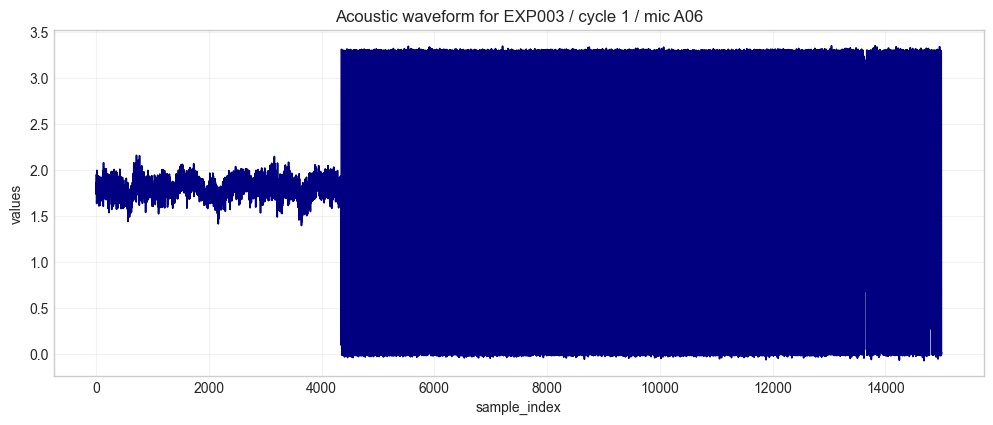

Waveform shape: (14999,)
Waveform dtype: float32


In [6]:
waveform_values = np.asarray(waveform.values, dtype=float)
sample_index = np.arange(waveform_values.size)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(sample_index, waveform_values, color="navy", linewidth=1.2)
ax.set_title(
    f"Acoustic waveform for {SELECTED_EXPERIMENT_ID} / cycle {SELECTED_CYCLE_ID} / mic {SELECTED_MICROPHONE_LABEL}"
)
ax.set_xlabel("sample_index")
ax.set_ylabel("values")
ax.grid(True, alpha=0.25)
plt.show()

print(f"Waveform shape: {waveform.shape}")
print(f"Waveform dtype: {waveform.dtype}")